In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
goog_daily = pd.read_csv("GOOG_PRICE_MOVEMENT_Data.csv")
goog_daily=goog_daily.rename(columns={"Price":"Date"})
goog_daily=goog_daily.drop([0,1])

goog_daily.tail(10)

,Date,Open,High,Low,Close,Volume
2487,2025-09-25,244.83999633789062,247.31500244140625,241.64999389648438,246.57000732421875,17379800
2488,2025-09-26,247.78500366210938,250.1199951171875,246.63999938964844,247.17999267578125,16594600
2489,2025-09-29,248.27499389648438,251.6479949951172,243.1999969482422,244.36000061035156,23157200
2490,2025-09-30,243.05999755859375,243.6750030517578,239.5709991455078,243.5500030517578,22541200
2491,2025-10-01,241.17999267578125,247.14999389648438,239.1999969482422,245.5399932861328,23967700
2492,2025-10-02,245.63999938964844,247.63499450683594,243.10499572753906,246.42999267578125,20657500
2493,2025-10-03,245.22999572753906,247.1179962158203,242.47000122070312,246.4499969482422,19941400
2494,2025-10-06,245.77999877929688,252.1999969482422,245.69000244140625,251.50999450683594,18309000
2495,2025-10-07,248.92999267578125,251.5500030517578,246.80999755859375,247.1300048828125,13811200
2496,2025-10-08,246.1999969482422,247.25999450683594,245.08999633789062,245.4600067138672,14123000


Below I am adding new data to the net income table so I can create rolling data for the entire daily set

In [ ]:
long_data = pd.read_csv("GOOG_Long net income data - Sheet1.csv")
# long_data.info()
cleaned_column = long_data["Net income (m)"].str.replace(",", "")
long_data["Net income (m)"] = pd.to_numeric(cleaned_column)
long_data["Net income (m)"] = long_data["Net income (m)"] * 1000000

cleaned_column = long_data["Shares Outstanding (m)"].str.replace(",", "")
long_data["Shares Outstanding (m)"] = pd.to_numeric(cleaned_column)
long_data["Shares Outstanding (m)"] = long_data["Shares Outstanding (m)"] * 1000000

long_data=long_data.sort_values(by="date")

long_data=long_data.rename(columns={"date":"Date Filed", "Net income (m)":"Net Income"})
long_data=long_data.rename(columns={"Shares Outstanding (m)":"Shares Outstanding"})
long_data.head(10)
long_data.info()

long_data['ttm_net_income'] = long_data['Net Income'].rolling(window=4).sum()
long_data['ttm_eps'] = long_data['ttm_net_income'] / long_data['Shares Outstanding']
long_data=long_data.dropna()
long_data.head(25)
# long_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53 entries, 52 to 0
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date Filed          53 non-null     object 
 1   Net Income          53 non-null     float64
 2   Shares Outstanding  53 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.7+ KB


,Date Filed,Net Income,Shares Outstanding,ttm_net_income,ttm_eps
49,2013-03-31,3.346000e+09,1.346700e+10,1.119300e+10,0.831143
48,2013-06-30,3.228000e+09,1.353300e+10,1.163600e+10,0.859824
47,2013-09-30,2.970000e+09,1.356900e+10,1.243000e+10,0.916059
46,2013-12-31,3.189000e+09,1.473900e+10,1.273300e+10,0.863899
45,2014-03-31,3.452000e+09,1.370400e+10,1.283900e+10,0.936880
44,2014-06-30,3.351000e+09,1.483300e+10,1.296200e+10,0.873862
43,2014-09-30,2.739000e+09,1.485700e+10,1.273100e+10,0.856902
42,2014-12-31,4.594000e+09,1.484000e+10,1.413600e+10,0.952561
41,2015-03-31,3.515000e+09,1.484700e+10,1.419900e+10,0.956355
40,2015-06-30,3.409000e+09,1.486000e+10,1.425700e+10,0.959421


In [ ]:
#convert from sting to date
goog_daily['Date'] = pd.to_datetime(goog_daily['Date'])
long_data['Date Filed'] = pd.to_datetime(long_data['Date Filed'])
goog_daily.head()

,Date,Open,High,Low,Close,Volume
2,2015-11-05,36.22559957121236,36.72269754603378,36.22559957121236,36.313995361328125,37232000
3,2015-11-06,36.32641346062947,36.52058414060551,36.10343676141681,36.43864440917969,30232000
4,2015-11-09,36.26184826512942,36.48581759399499,35.72701038679302,35.99815368652344,41396000
5,2015-11-10,35.9738205732517,36.28121480698938,35.68082366351539,36.168487548828125,32160000
6,2015-11-11,36.37408033872511,36.79817623817985,36.26333839880317,36.52008056640625,27328000


In [ ]:
goog_daily_plus = pd.merge_asof( #merge goog daily with long data which contains eps, etc
    goog_daily,
    long_data[['Date Filed', 'ttm_eps']],
    left_on='Date',
    right_on='Date Filed',
    direction='backward'
)

for col in goog_daily_plus.select_dtypes(include=['object']).columns:
    if goog_daily_plus[col].dtype == 'object':
        goog_daily_plus[col] = goog_daily_plus[col].replace({',': '', '\$': ''}, regex=True)
        goog_daily_plus[col] = pd.to_numeric(goog_daily_plus[col], errors='coerce')


goog_daily_plus=goog_daily_plus.drop(columns={"Date Filed"})
goog_daily_plus.head(10)

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3589847829.py:11: SyntaxWarning: invalid escape sequence '\$'
  goog_daily_plus[col] = goog_daily_plus[col].replace({',': '', '\$': ''}, regex=True)


,Date,Open,High,Low,Close,Volume,ttm_eps
0,2015-11-05,36.225600,36.722698,36.225600,36.313995,37232000,1.039091
1,2015-11-06,36.326413,36.520584,36.103437,36.438644,30232000,1.039091
2,2015-11-09,36.261848,36.485818,35.727010,35.998154,41396000,1.039091
3,2015-11-10,35.973821,36.281215,35.680824,36.168488,32160000,1.039091
4,2015-11-11,36.374080,36.798176,36.263338,36.520081,27328000,1.039091
5,2015-11-12,36.301580,36.639270,36.184632,36.313004,36744000,1.039091
6,2015-11-13,36.210700,36.309026,35.592926,35.606335,41510000,1.039091
7,2015-11-16,35.536813,36.226592,35.324766,36.200275,38118000,1.039091
8,2015-11-17,36.216662,36.343544,35.905638,36.018517,30218000,1.039091
9,2015-11-18,36.131742,36.818540,36.102936,36.748520,33686000,1.039091


I am adding features below. SMA and EMA have to do with a moving average. I think that we will be able to tune the length of the average to acheive a higher accuracy. I will start with the 20, 50, and 200 day moving averages (50).

In [ ]:
goog_daily_plus["PE Ratio"]=goog_daily_plus["Close"]/goog_daily_plus["ttm_eps"]
goog_daily_plus['tr_1'] = goog_daily_plus['High'] - goog_daily_plus['Low']
goog_daily_plus['tr_2'] = abs(goog_daily_plus['High'] - goog_daily_plus['Close'].shift(1))
goog_daily_plus['tr_3'] = abs(goog_daily_plus['Low'] - goog_daily_plus['Close'].shift(1))
goog_daily_plus['Max_Swing'] = goog_daily_plus[['tr_1', 'tr_2', 'tr_3']].max(axis=1)
goog_daily_plus["20-Day Average Swing"] = goog_daily_plus['Max_Swing'].rolling(window=20).mean()

#Exponential Moving average
goog_daily_plus["EMA_20"]=goog_daily_plus["Close"].ewm(span=20,adjust=True).mean()
goog_daily_plus["EMA_50"]=goog_daily_plus["Close"].ewm(span=50,adjust=True).mean()
#Simple Moving Average
goog_daily_plus["SMA_20"]=goog_daily_plus["Close"].rolling(window=20).mean()
goog_daily_plus["SMA_50"]=goog_daily_plus["Close"].rolling(window=50).mean()

#Volume moving average
goog_daily_plus['VMA_20'] = goog_daily_plus['Volume'].rolling(window=20).mean()
goog_daily_plus['VMA_50'] = goog_daily_plus['Volume'].rolling(window=50).mean()

#Relative Volume
goog_daily_plus['Relative Volume_20'] = goog_daily_plus["Volume"]/goog_daily_plus['VMA_20']
goog_daily_plus['Relative Volume_50'] = goog_daily_plus["Volume"]/goog_daily_plus['VMA_50']

goog_daily_plus.info()
# goog_daily_plus.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  2495 non-null   datetime64[ns]
 1   Open                  2495 non-null   float64       
 2   High                  2495 non-null   float64       
 3   Low                   2495 non-null   float64       
 4   Close                 2495 non-null   float64       
 5   Volume                2495 non-null   int64         
 6   ttm_eps               2495 non-null   float64       
 7   PE Ratio              2495 non-null   float64       
 8   tr_1                  2495 non-null   float64       
 9   tr_2                  2494 non-null   float64       
 10  tr_3                  2494 non-null   float64       
 11  Max_Swing             2495 non-null   float64       
 12  20-Day Average Swing  2476 non-null   float64       
 13  EMA_20            

Below I want to take features from the above table that I will use in the transformer to predict future price movement

In [ ]:
#need to add sentiment score to this table (from vader analysis)
final_df=goog_daily_plus[["Date", "Close", "SMA_20", "SMA_50", "EMA_20", "EMA_50", "Volume", "Relative Volume_20", "Relative Volume_50", "20-Day Average Swing", "PE Ratio"]]
final_df=final_df.rename(columns={"Close":"Price"})
final_df=final_df.drop(final_df.index[:49])
# final_df.set_index("Date", inplace=True)
final_df.head(5)
# final_df.info()


,Date,Price,SMA_20,SMA_50,EMA_20,EMA_50,Volume,Relative Volume_20,Relative Volume_50,20-Day Average Swing,PE Ratio
49,2016-01-19,34.851009,36.568006,36.824709,36.182580,36.635280,45362000,1.092763,1.143419,0.877227,32.798618
50,2016-01-20,34.685139,36.466550,36.792132,36.039095,36.547377,68900000,1.648026,1.709440,0.920952,32.642516
51,2016-01-21,35.089371,36.364299,36.765146,35.948146,36.482040,48244000,1.129992,1.186352,0.955814,33.022942
52,2016-01-22,36.016033,36.302845,36.765504,35.954643,36.461273,40236000,0.928370,0.989995,0.986156,33.895033
53,2016-01-25,35.341648,36.206902,36.748967,35.895999,36.411644,34234000,0.787236,0.841459,1.009646,33.260363


<Axes: >

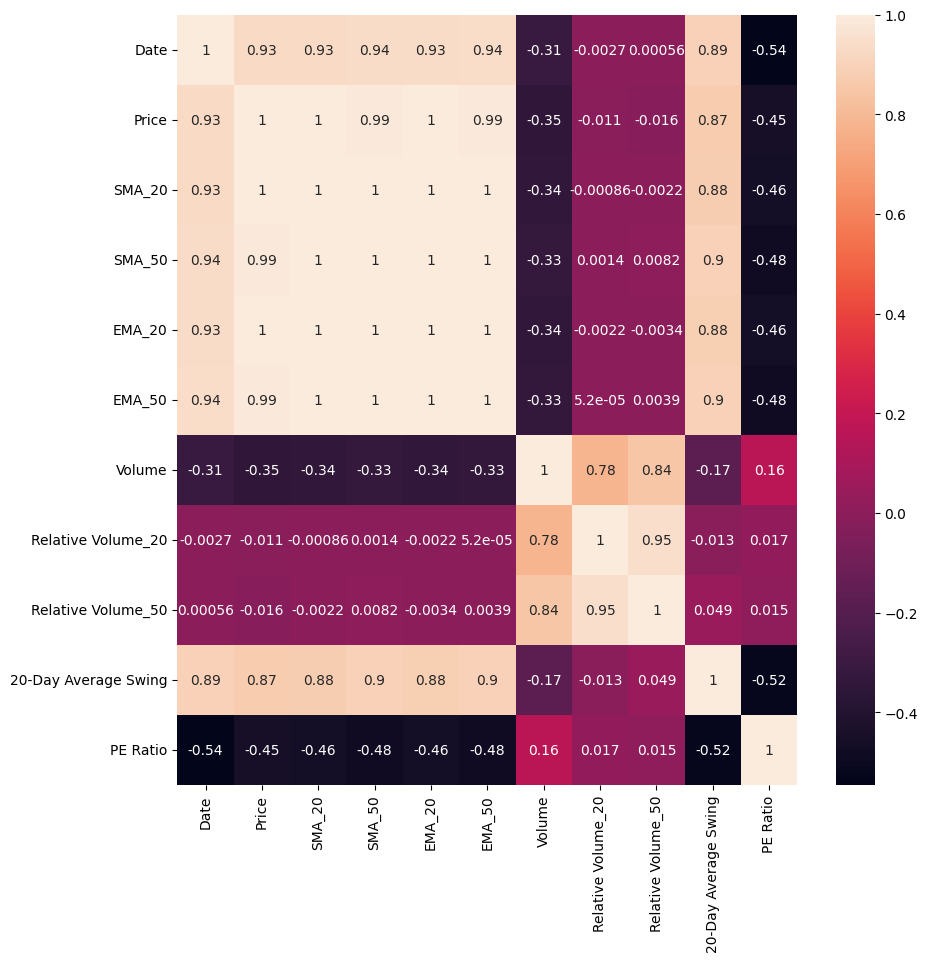

In [ ]:
# final_df.to_csv("GOOG_final_DF.csv", index=False)
corr_mat=final_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_mat,annot=True)

<Axes: >

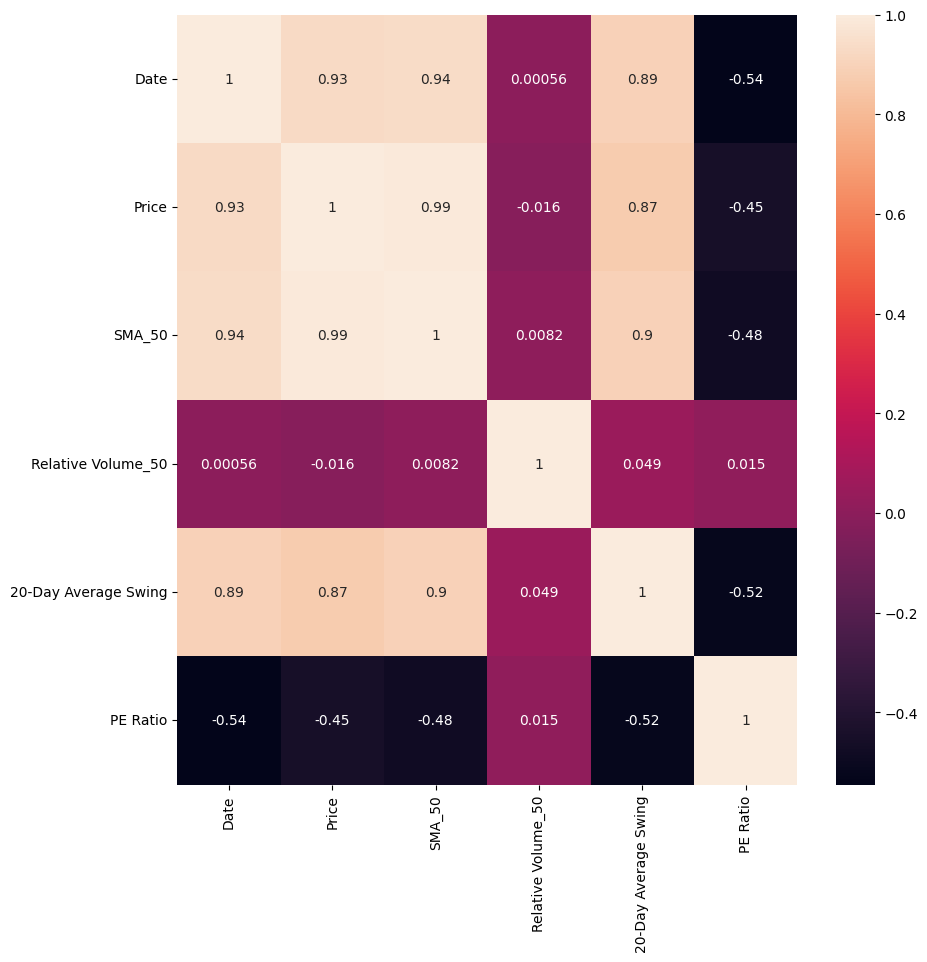

In [ ]:
final_df=pd.read_csv("GOOG_final_DF.csv")
final_df['Date'] = pd.to_datetime(final_df['Date'])
reduced_df=final_df.drop(columns=["Volume","SMA_20","EMA_20", "EMA_50","Relative Volume_20"])
# reduced_df.head()
reduced_corr=reduced_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(reduced_corr,annot=True)

LSTM implimentation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


Below is an attempt with the full Final Dataframe

In [ ]:
if 'Date' in final_df.columns:
    final_df = final_df.set_index('Date')


target_col = 'Price'
feature_cols = [col for col in final_df.columns if col != target_col]
n_features = len(feature_cols)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

df_target = final_df[[target_col]].values
df_features = final_df[feature_cols].values

scaled_target = target_scaler.fit_transform(df_target)
scaled_features = feature_scaler.fit_transform(df_features)

scaled_data = np.concatenate([scaled_target, scaled_features], axis=1)

train_split_ratio = 0.8
train_size = int(len(scaled_data) * train_split_ratio)
test_size = len(scaled_data) - train_size

train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:, :]

print(f"Number of features (not including target): {n_features}")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Number of features (not including target): 9
Training samples: 1956
Test samples: 490


In [ ]:
def create_sequences_simple(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

seq_length = 180
n_all_features = scaled_data.shape[1]

X_train, y_train = create_sequences_simple(train_data, seq_length)

test_data_with_overlap = scaled_data[train_size - seq_length:, :]
X_test, y_test_scaled = create_sequences_simple(test_data_with_overlap, seq_length)

y_test_actual = final_df[target_col].iloc[train_size:].values
# print(X_train)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1776, 180, 10)
y_train shape: (1776,)


In [ ]:
n_timesteps = 180
n_features = 9

model = Sequential()

model.add(LSTM(units=200, return_sequences=True, input_shape=(seq_length, n_all_features)))
model.add(Dropout(0.2))

model.add(LSTM(units=200, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=200, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=100, activation='relu'))

model.add(Dense(units=1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 200)        │       168,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 90, 200)        │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 830,601 (3.17 MB)

 Trainable params: 830,601 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

print("Training new model...")
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test_scaled),
    verbose=1
)
print("Model training complete.")

Training new model...
Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0077 - val_loss: 0.0064
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.4220e-04 - val_loss: 0.0073
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.0634e-04 - val_loss: 0.0048
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 7.2975e-04 - val_loss: 0.0059
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.6721e-04 - val_loss: 0.0099
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.8076e-04 - val_loss: 0.0057
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.6691e-04 - val_loss: 0.0051
Epoch 8/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.6858e-04 - val_loss: 0.0089
Epoch 9/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.6745e-04 - val_loss: 0.0027
Epoch 10/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.4618e-04 - val_loss: 0.0028
Epoch 11/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4.7061e-04 - val_los

In [ ]:
model.save_weights("Large_GOOG_weights.weights.h5")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Test Root Mean Squared Error (RMSE): 14.497348109436775


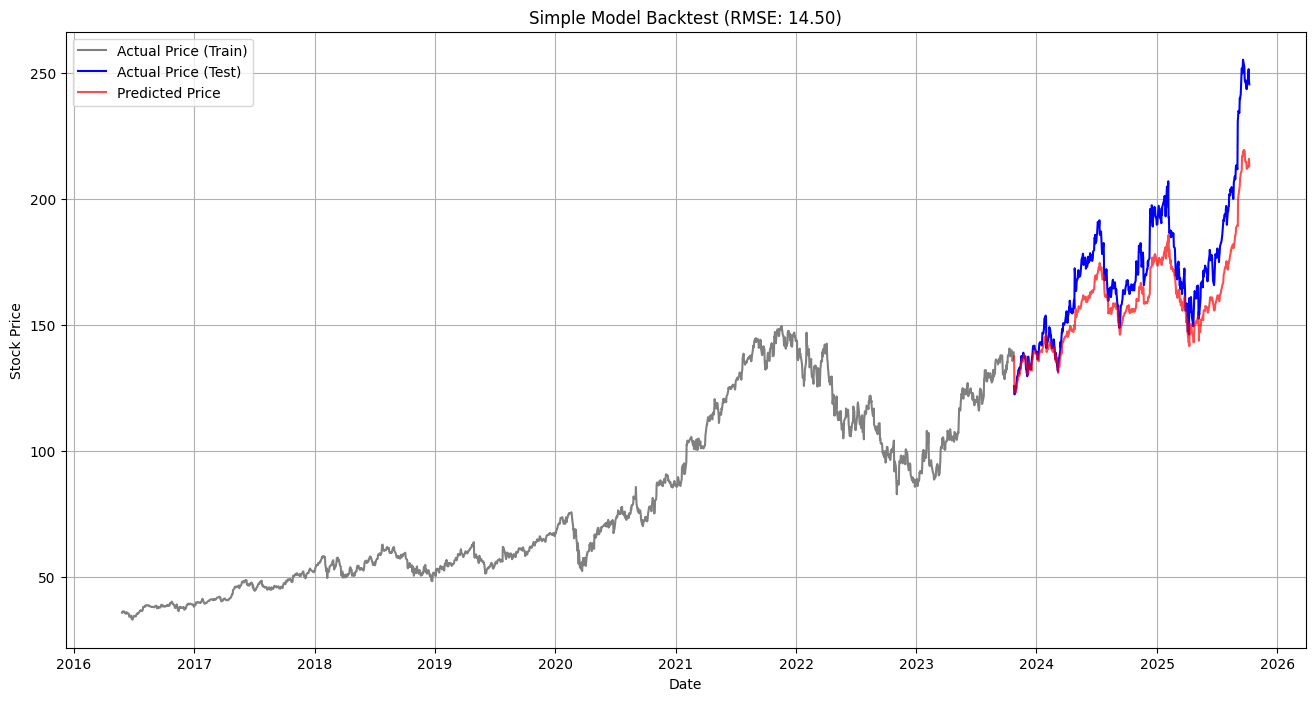

In [ ]:
from sklearn.metrics import mean_squared_error

predictions_scaled = model.predict(X_test)

predictions = target_scaler.inverse_transform(predictions_scaled)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Test Root Mean Squared Error (RMSE): {rmse}')

train_dates = final_df.index[seq_length:train_size]
test_dates = final_df.index[train_size:]
actual_train_data = final_df[target_col].iloc[seq_length:train_size]

plt.figure(figsize=(16, 8))
plt.plot(train_dates, actual_train_data, color='gray', label='Actual Price (Train)')
plt.plot(test_dates, y_test_actual, color='blue', label='Actual Price (Test)')
plt.plot(test_dates, predictions, color='red', label='Predicted Price', alpha=0.7)
plt.title(f'Simple Model Backtest (RMSE: {rmse:.2f})')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

Starting simple forecast loop for 90 days...
Forecast loop complete.


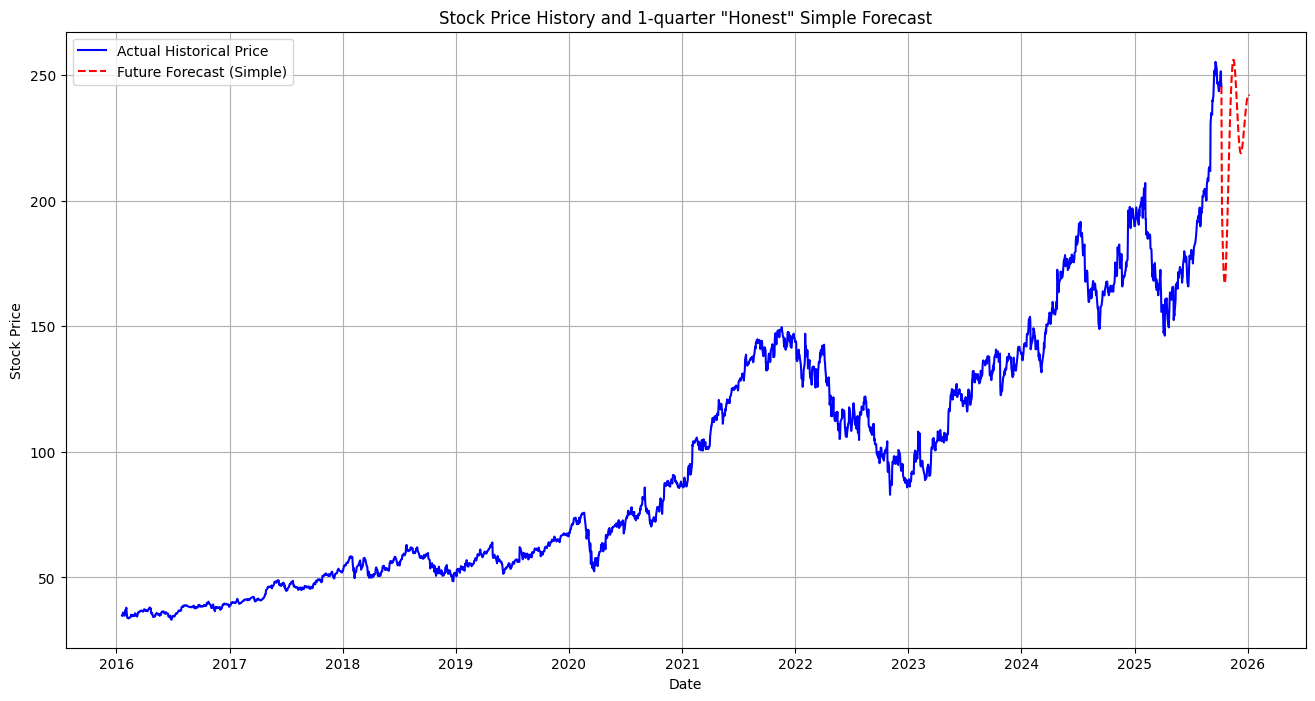

In [ ]:
n_future_days = 90
seq_length = 180

last_known_sequence = scaled_data[-seq_length:]

future_predictions_scaled = []

current_sequence = last_known_sequence

print(f"Starting simple forecast loop for {n_future_days} days...")
for i in range(n_future_days):
    current_sequence_reshaped = np.reshape(current_sequence, (1, seq_length, n_all_features))

    next_prediction_scaled = model.predict(current_sequence_reshaped, verbose=0)

    future_predictions_scaled.append(next_prediction_scaled[0][0])

    new_row = current_sequence[-1, :].copy()

    new_row[0] = next_prediction_scaled[0][0]

    current_sequence = np.append(current_sequence, [new_row], axis=0)
    current_sequence = current_sequence[1:, :]

print("Forecast loop complete.")

predictions = target_scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

last_date = final_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_future_days)

last_actual_price = final_df[target_col].iloc[-1]
last_actual_date = final_df.index[-1]

plot_predictions = np.insert(predictions, 0, last_actual_price)
plot_dates = future_dates.insert(0, last_actual_date)

plt.figure(figsize=(16, 8))
plt.plot(final_df.index, final_df[target_col], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='--', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

Attempt with reduced dataframe

In [ ]:
if 'Date' in reduced_df.columns:
    reduced_df = reduced_df.set_index('Date')


target_col = 'Price'
feature_cols = [col for col in reduced_df.columns if col != target_col]
n_features = len(feature_cols)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

df_target = reduced_df[[target_col]].values
df_features = reduced_df[feature_cols].values

scaled_target = target_scaler.fit_transform(df_target)
scaled_features = feature_scaler.fit_transform(df_features)

scaled_data = np.concatenate([scaled_target, scaled_features], axis=1)

train_split_ratio = 0.8
train_size = int(len(scaled_data) * train_split_ratio)
test_size = len(scaled_data) - train_size

train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:, :]

print(f"Number of features (not including target): {n_features}")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Number of features (not including target): 4
Training samples: 1956
Test samples: 490


In [ ]:
def create_sequences_simple(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

seq_length = 180
n_all_features = scaled_data.shape[1]

X_train, y_train = create_sequences_simple(train_data, seq_length)

test_data_with_overlap = scaled_data[train_size - seq_length:, :]
X_test, y_test_scaled = create_sequences_simple(test_data_with_overlap, seq_length)

y_test_actual = reduced_df[target_col].iloc[train_size:].values
# print(X_train)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1776, 180, 5)
y_train shape: (1776,)


In [ ]:
reduced_df.columns

Index(['Price', 'SMA_50', 'Relative Volume_50', '20-Day Average Swing',
       'PE Ratio'],
      dtype='object')

In [ ]:
n_timesteps = 180
n_features = 4

model = Sequential()

model.add(LSTM(units=400, return_sequences=True, input_shape=(seq_length, n_all_features)))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=200, activation='relu'))

model.add(Dense(units=100, activation='relu'))

# model.add(Dense(units=n_features))
model.add(Dense(units=1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 180, 400)       │       649,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180, 400)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 180, 400)       │     1,281,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 180, 400)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 180, 400)       │     1,281,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 180, 400)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 400)            │     1,281,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,594,801 (17.53 MB)

 Trainable params: 4,594,801 (17.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

print("Training new model...")
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test_scaled),
    verbose=1
)
print("Model training complete.")



Training new model...
Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.1206 - val_loss: 0.0104
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 7.9947e-04 - val_loss: 0.0142
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 7.2487e-04 - val_loss: 0.0149
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 6.5791e-04 - val_loss: 0.0106
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 7.4206e-04 - val_loss: 0.0115
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 6.2110e-04 - val_loss: 0.0112
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 5.6829e-04 - val_loss: 0.0095
Epoch 8/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 5.9921e-04 - val_loss: 0.0111
Epoch 9/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 4.5481e-04 - val_loss: 0.0122
Epoch 10/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 4.6404e-04 - val_loss: 0.0040
Epoch 11/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 7.9436e-04 - val_l

In [ ]:
model.save_weights("reduced_weights_Large_model1.weights.h5")

In [ ]:
model.load_weights("reduced_weights.weights.h5")


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Test Root Mean Squared Error (RMSE): 10.000480230643346


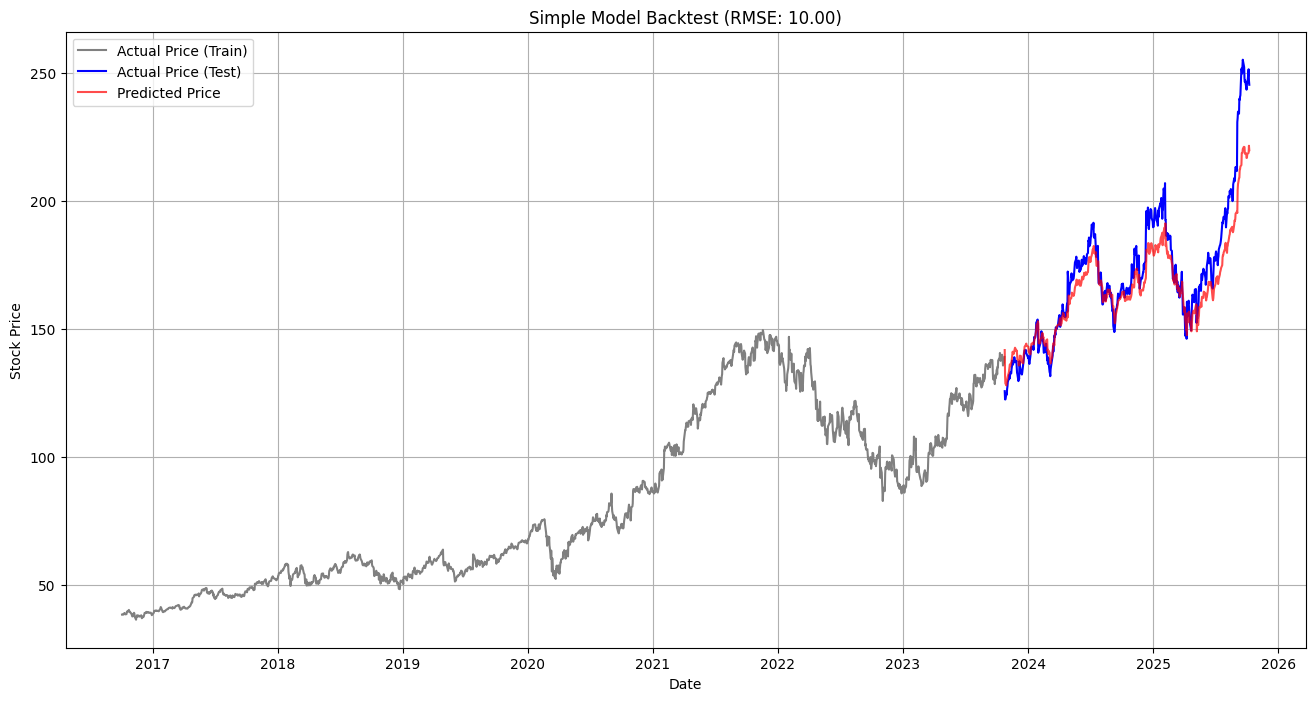

In [ ]:
from sklearn.metrics import mean_squared_error

predictions_scaled = model.predict(X_test)

predictions = target_scaler.inverse_transform(predictions_scaled)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Test Root Mean Squared Error (RMSE): {rmse}')

train_dates = final_df.index[seq_length:train_size]
test_dates = final_df.index[train_size:]
actual_train_data = final_df[target_col].iloc[seq_length:train_size]

plt.figure(figsize=(16, 8))
plt.plot(train_dates, actual_train_data, color='gray', label='Actual Price (Train)')
plt.plot(test_dates, y_test_actual, color='blue', label='Actual Price (Test)')
plt.plot(test_dates, predictions, color='red', label='Predicted Price', alpha=0.7)
plt.title(f'Simple Model Backtest (RMSE: {rmse:.2f})')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

Starting simple forecast loop for 180 days...
Forecast loop complete.


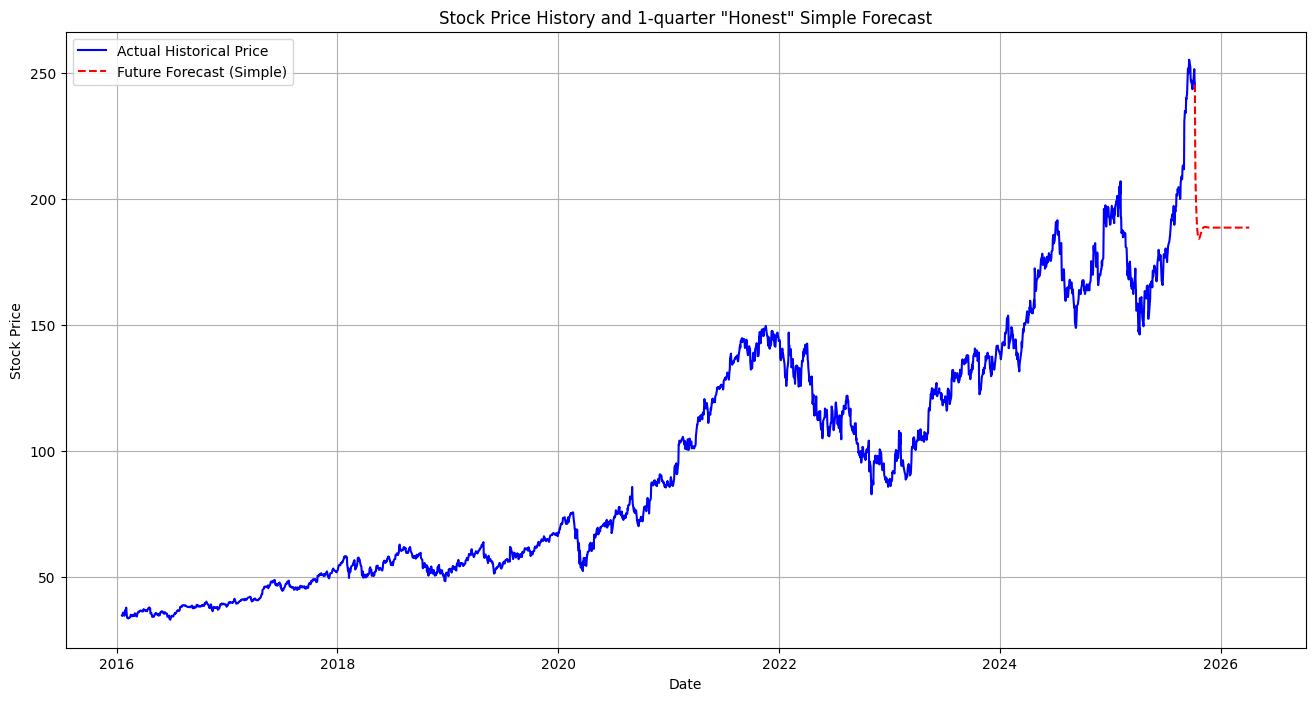

In [ ]:
n_future_days = 180
seq_length = 180

last_known_sequence = scaled_data[-seq_length:]

future_predictions_scaled = []

current_sequence = last_known_sequence

print(f"Starting simple forecast loop for {n_future_days} days...")
for i in range(n_future_days):
    current_sequence_reshaped = np.reshape(current_sequence, (1, seq_length, n_all_features))

    next_prediction_scaled = model.predict(current_sequence_reshaped, verbose=0)

    future_predictions_scaled.append(next_prediction_scaled[0][0])

    new_row = current_sequence[-1, :].copy()

    new_row[0] = next_prediction_scaled[0][0]

    current_sequence = np.append(current_sequence, [new_row], axis=0)
    current_sequence = current_sequence[1:, :]

print("Forecast loop complete.")

predictions = target_scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

last_date = reduced_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_future_days)

last_actual_price = reduced_df[target_col].iloc[-1]
last_actual_date = reduced_df.index[-1]

plot_predictions = np.insert(predictions, 0, last_actual_price)
plot_dates = future_dates.insert(0, last_actual_date)

plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index, reduced_df[target_col], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='--', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

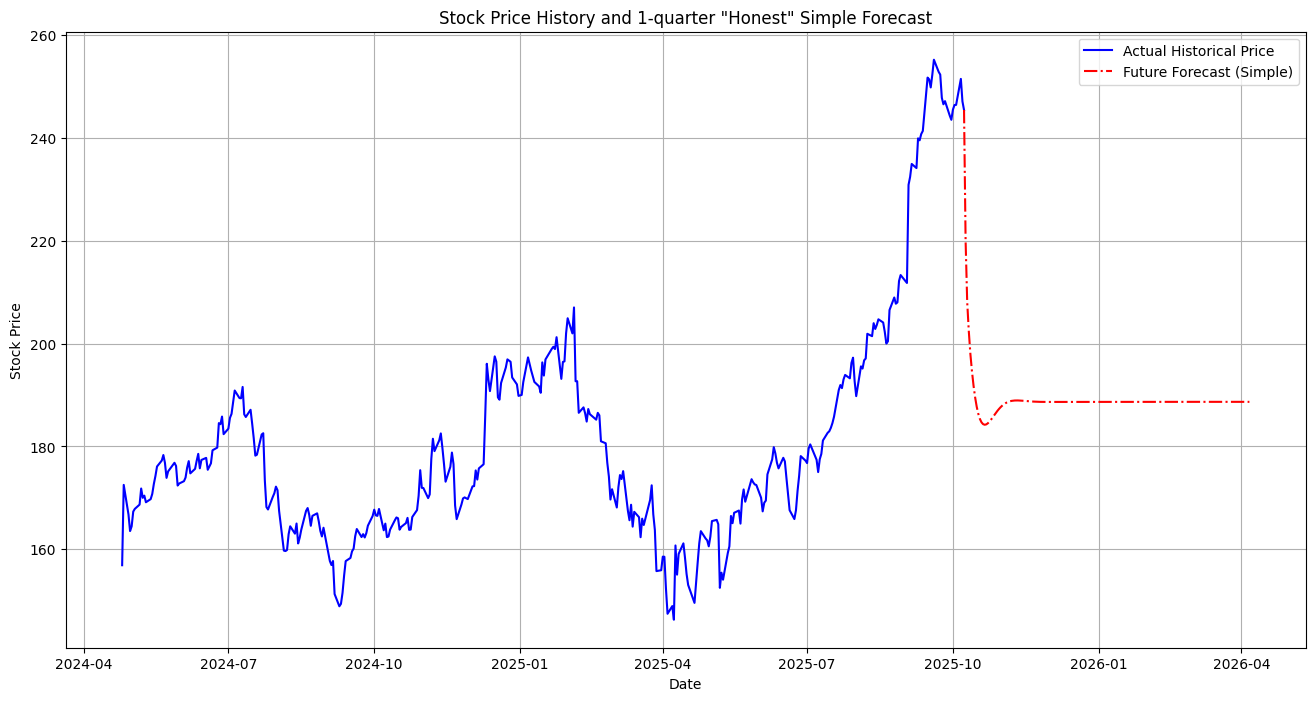

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index[-365:], reduced_df[target_col][-365:], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='-.', label='Future Forecast (Simple)')
plt.title('Stock Price History and 1-quarter "Honest" Simple Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

Single Feature


In [ ]:
# --- Data Preparation and Scaling (Single Feature) ---

target_col = 'Price'
df_target = reduced_df[[target_col]].values

# Use a dedicated scaler for the single 'Price' feature
target_scaler_single = MinMaxScaler(feature_range=(0, 1))
scaled_target_data = target_scaler_single.fit_transform(df_target)

# --- Splitting ---
seq_length = 180
train_split_ratio = 0.8
train_size = int(len(scaled_target_data) * train_split_ratio)
train_data_single = scaled_target_data[0:train_size, :]

# --- Sequence Creation for Single Feature ---
def create_sequences_single_feature(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        # X: sequence of past 'seq_length' data points
        X.append(data[i-seq_length:i, 0])
        # y: the next data point (the target at index 0)
        y.append(data[i, 0])

    # X needs shape (n_samples, seq_length, 1) for LSTM
    X = np.array(X)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    return X, np.array(y)

# Create train sequences
X_train_single, y_train_single = create_sequences_single_feature(train_data_single, seq_length)
n_features_single = 1

In [ ]:
n_timesteps = 180
n_features_single = 1

model_single = Sequential()

# Input shape is (seq_length, 1)
model_single.add(LSTM(units=100, return_sequences=True, input_shape=(n_timesteps, n_features_single)))
model_single.add(Dropout(0.2))

model_single.add(LSTM(units=100, return_sequences=True))
model_single.add(Dropout(0.2))

model_single.add(LSTM(units=100, return_sequences=False))
model_single.add(Dropout(0.2))

model_single.add(Dense(units=50, activation='relu'))
model_single.add(Dense(units=1))

model_single.compile(optimizer='adam', loss='mean_squared_error')

print("Starting single feature model training...")
# Only 20 epochs to demonstrate the fix, feel free to increase this.
history_single = model_single.fit(
    X_train_single,
    y_train_single,
    epochs=20, # Reduced epochs for demonstration, increase if needed
    batch_size=32,
    verbose=1
)
print("Single feature model training complete.")

Starting single feature model training...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0095
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 8.3940e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 7.2021e-04
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.7210e-04
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.2632e-04
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.1159e-04
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.9130e-04
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.9001e-04
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.0613e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.9321e-04
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.4862e-04
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.9262e-04
Epoch 13/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.3434e-04
Epoch 14/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/s

Starting single-feature future price forecast for 180 days...
Future forecast loop complete.


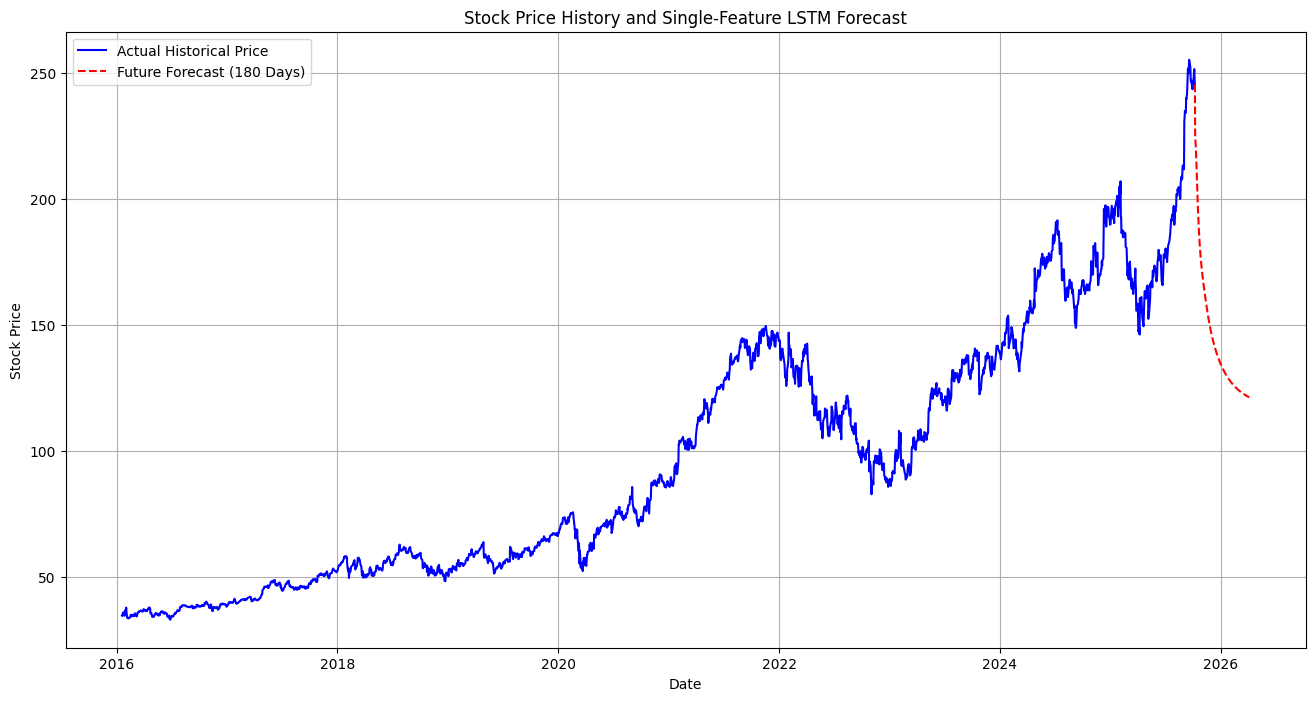

In [ ]:
n_future_days = 180
seq_length = 180

# Get the last 'seq_length' days of SCALED data (shape: 180, 1)
last_known_sequence = scaled_target_data[-seq_length:]

future_predictions_scaled = []
current_sequence = last_known_sequence.copy()

print(f"Starting single-feature future price forecast for {n_future_days} days...")

# The loop runs for the number of days we want to forecast
for i in range(n_future_days):

    # 1. Reshape the current sequence for the LSTM model: (1, seq_length, 1)
    current_sequence_reshaped = np.reshape(current_sequence, (1, seq_length, 1))

    # 2. Predict the next day's price (still scaled) - Output shape is (1, 1)
    next_prediction_scaled = model_single.predict(current_sequence_reshaped, verbose=0)

    # 3. Store the prediction (the scalar value)
    future_predictions_scaled.append(next_prediction_scaled[0][0])

    # 4. Update the current_sequence for the next prediction (Iterative/Autoregressive step)

    # Drop the oldest day (current_sequence[1:] has shape (179, 1))
    # Append the new prediction (next_prediction_scaled has shape (1, 1))
    # Concatenate along axis=0 to get back to the required (180, 1) shape.
    current_sequence = np.concatenate([current_sequence[1:], next_prediction_scaled], axis=0)

print("Future forecast loop complete.")

# Inverse transform the scaled predictions to get actual dollar values
predictions_actual_single = target_scaler_single.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# --- Plotting the Historical Data + Future Forecast ---

last_actual_date = reduced_df.index[-1]

# Generate future dates starting from the day after the last historical date
future_dates = pd.date_range(start=last_actual_date + pd.Timedelta(days=1), periods=n_future_days)

# Prepare predictions for plotting, starting from the last known actual price
last_actual_price = reduced_df[target_col].iloc[-1]
plot_predictions = np.insert(predictions_actual_single, 0, last_actual_price)
plot_dates = future_dates.insert(0, last_actual_date)

plt.figure(figsize=(16, 8))
plt.plot(reduced_df.index, reduced_df[target_col], color='blue', label='Actual Historical Price')
plt.plot(plot_dates, plot_predictions, color='red', linestyle='--', label='Future Forecast (180 Days)')
plt.title('Stock Price History and Single-Feature LSTM Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
final_df=pd.read_csv("GOOG_final_DF.csv")
final_df['Date'] = pd.to_datetime(final_df['Date'])
reduced_df=final_df.drop(columns=["Volume","SMA_20","EMA_20", "EMA_50","Relative Volume_20"])
reduced_df.head()

,Date,Price,SMA_50,Relative Volume_50,20-Day Average Swing,PE Ratio
0,2016-01-19,34.851009,36.824709,1.143419,0.877227,32.798618
1,2016-01-20,34.685139,36.792132,1.709440,0.920952,32.642516
2,2016-01-21,35.089371,36.765146,1.186352,0.955814,33.022942
3,2016-01-22,36.016033,36.765504,0.989995,0.986156,33.895033
4,2016-01-25,35.341648,36.748967,0.841459,1.009646,33.260363


In [ ]:
sentiment_df = pd.read_csv('Google Sentiment Analysis.csv')
sentiment_df.head()
#sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
#sentiment_df.rename(columns={'date':'Date', 'FinBERT_Score (-1, 1)':'Sentiment Score'}, inplace=True)
#sentiment_df.drop(columns=['Article_Count'], inplace=True)
#reduced_df = reduced_df[reduced_df['Date'].isin(sentiment_df['Date'])]
#reduced_df = reduced_df.merge(sentiment_df, on='Date')

,date,"FinBERT_Score (-1, 1)",Article_Count
0,2020-01-01,-0.017603,185
1,2020-01-02,0.000567,309
2,2020-01-03,-0.223617,233
3,2020-01-04,-0.092341,106
4,2020-01-05,-0.109051,55


<Axes: >

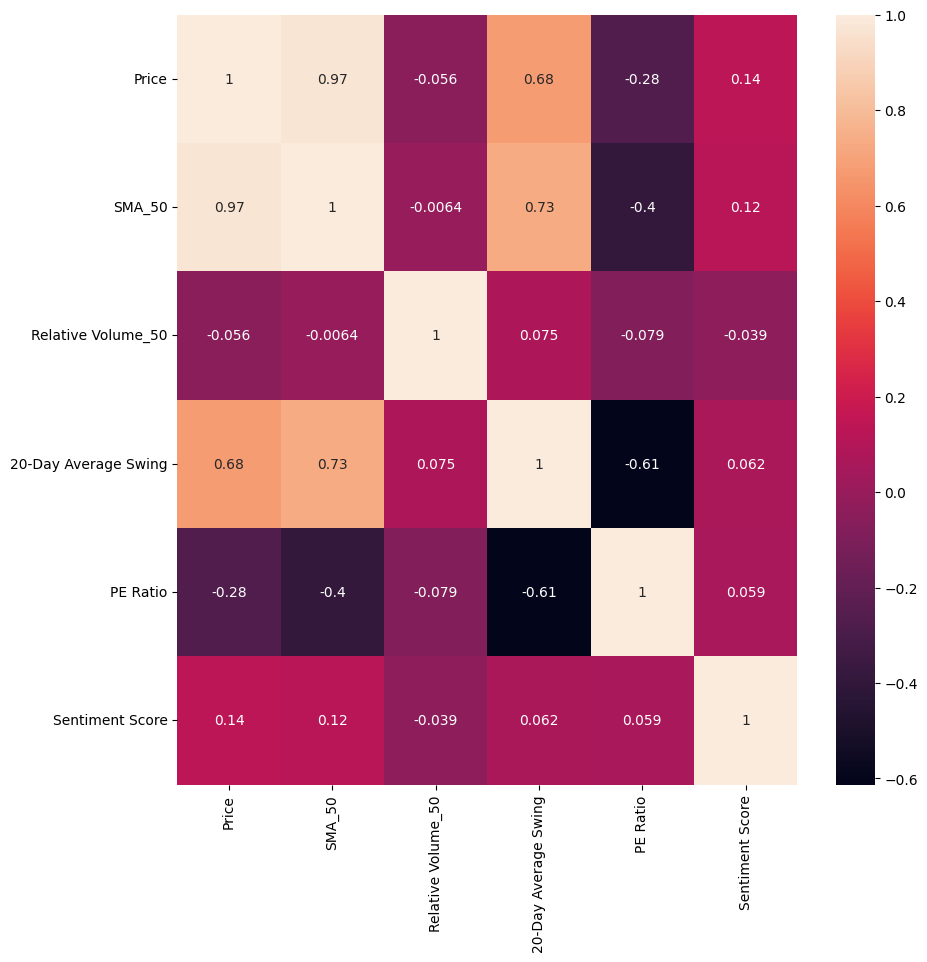

In [ ]:
reduced_corr=reduced_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(reduced_corr,annot=True)

In [ ]:
if 'Date' in reduced_df.columns:
    reduced_df = reduced_df.set_index('Date')


target_col = 'Price'
feature_cols = [col for col in reduced_df.columns if col != target_col]
n_features = len(feature_cols)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

df_target = reduced_df[[target_col]].values
df_features = reduced_df[feature_cols].values

scaled_target = target_scaler.fit_transform(df_target)
scaled_features = feature_scaler.fit_transform(df_features)

scaled_data = np.concatenate([scaled_target, scaled_features], axis=1)

train_split_ratio = 0.8
train_size = int(len(scaled_data) * train_split_ratio)
test_size = len(scaled_data) - train_size

train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size:, :]

print(f"Number of features (not including target): {n_features}")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Number of features (not including target): 5
Training samples: 1160
Test samples: 290


In [ ]:
def create_sequences_simple(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

seq_length = 180
n_all_features = scaled_data.shape[1]

X_train, y_train = create_sequences_simple(train_data, seq_length)

test_data_with_overlap = scaled_data[train_size - seq_length:, :]
X_test, y_test_scaled = create_sequences_simple(test_data_with_overlap, seq_length)

y_test_actual = reduced_df[target_col].iloc[train_size:].values
# print(X_train)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (980, 180, 6)
y_train shape: (980,)


In [ ]:
n_timesteps = 180
n_features = 5

model = Sequential()

model.add(LSTM(units=400, return_sequences=True, input_shape=(seq_length, n_all_features)))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=400, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=200, activation='relu'))

model.add(Dense(units=100, activation='relu'))

# model.add(Dense(units=n_features))
model.add(Dense(units=1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 180, 400)       │       651,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180, 400)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 180, 400)       │     1,281,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 180, 400)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 180, 400)       │     1,281,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 180, 400)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 400)            │     1,281,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,596,401 (17.53 MB)

 Trainable params: 4,596,401 (17.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

print("Training new model...")
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test_scaled),
    verbose=1
)
print("Model training complete.")

Training new model...
Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - loss: 0.1966 - val_loss: 0.0432
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0030 - val_loss: 0.0115
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0017 - val_loss: 0.0073
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0019 - val_loss: 0.0063
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0016 - val_loss: 0.0095
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0013 - val_loss: 0.0065
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0013 - val_loss: 0.0081
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0012 - val_loss: 0.0058
Epoch 9/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0012 - val_loss: 0.0070
Epoch 10/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0011 - val_loss: 0.0059
Epoch 11/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0011 - val_loss: 0.0104
Epoch 12/200
31/31 ━━━━━━━

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
Test Root Mean Squared Error (RMSE): 8.38404181784383


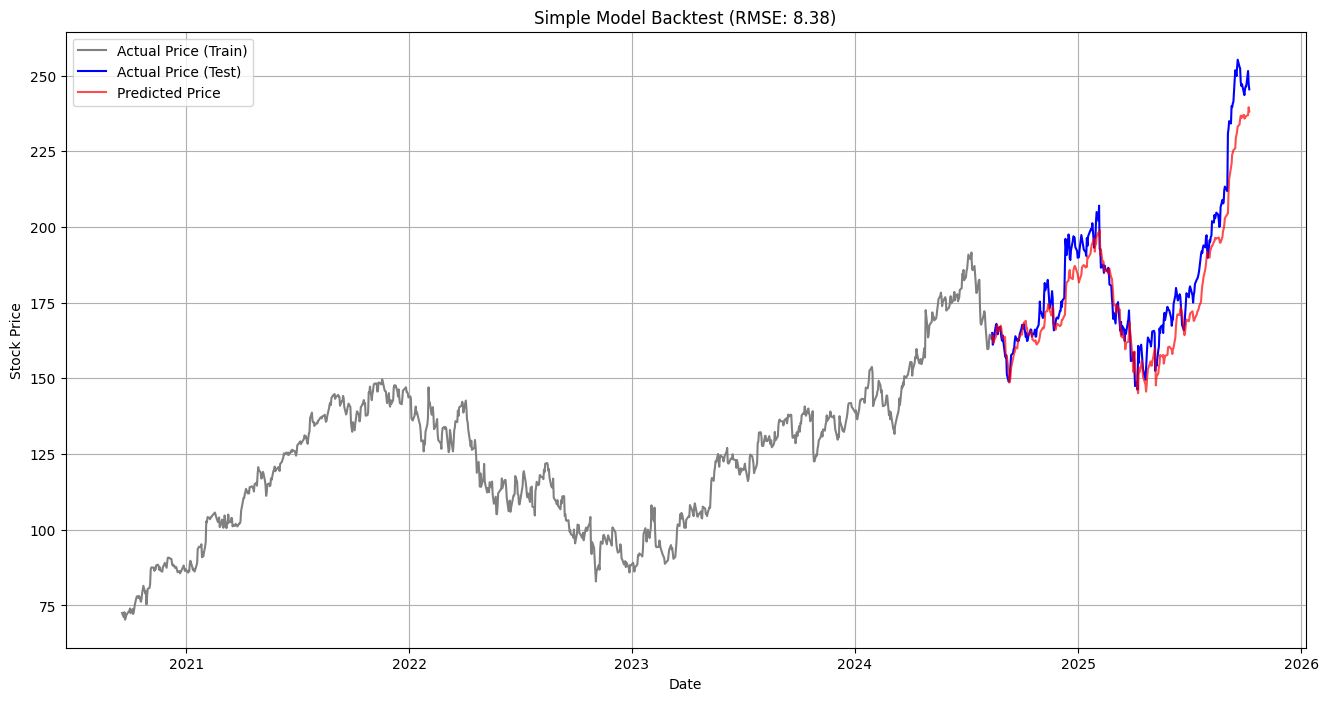

In [ ]:
from sklearn.metrics import mean_squared_error

predictions_scaled = model.predict(X_test)

predictions = target_scaler.inverse_transform(predictions_scaled)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Test Root Mean Squared Error (RMSE): {rmse}')

train_dates = reduced_df.index[seq_length:train_size]
test_dates = reduced_df.index[train_size:]
actual_train_data = reduced_df[target_col].iloc[seq_length:train_size]

plt.figure(figsize=(16, 8))
plt.plot(train_dates, actual_train_data, color='gray', label='Actual Price (Train)')
plt.plot(test_dates, y_test_actual, color='blue', label='Actual Price (Test)')
plt.plot(test_dates, predictions, color='red', label='Predicted Price', alpha=0.7)
plt.title(f'Simple Model Backtest (RMSE: {rmse:.2f})')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()